# Clustering - Mini-Project 3

***Edit this cell with your name(s), tutorial number and ID(s)***

---

Name: Omar Yasser

ID: 58-11176

Tutorial: 12

---

Name: Omar Essam

ID: 61-33437

Tutorial: 12

---

Name:

ID:

Tutorial:

---


## Dataset Description

The dataset file contains almost ~3000 different music genres aggregated from more than 160.000 songs collected from Spotify Web API.

Primary:

- genre (Music genre)

Numerical:

- acousticness (Ranges from 0 to 1)
- danceability (Ranges from 0 to 1)
- energy (Ranges from 0 to 1)
- duration_ms (Integer typically ranging from 200k to 300k)
- instrumentalness (Ranges from 0 to 1)
- valence (Ranges from 0 to 1)
- popularity (Ranges from 0 to 100)
- tempo (Float typically ranging from 50 to 150)
- liveness (Ranges from 0 to 1)
- loudness (Float typically ranging from -60 to 0 in decibels (dB))
- speechiness (Ranges from 0 to 1)


Categorical:

- key (All keys on octave encoded as values ranging from 0 to 11, starting on C as 0, C# as 1 and so on…)


**Recommended Reading for Data Understanding**: Spotify's documentation of audio features: https://developer.spotify.com/documentation/web-api/reference/tracks/get-audio-features/

**Acknowledgment**: This dataset was created and published by Yamaç Eren Ay on Kaggle.

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

%matplotlib inline
plt.style.use('fivethirtyeight')
sns.set_style('whitegrid')


In [53]:
df = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2025/refs/heads/main/data/music_genres.csv')
df.head()

,genres,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,21st century classical,0.979333,0.162883,1.602977e+05,0.071317,0.606834,0.361600,-31.514333,0.040567,75.336500,0.103783,27.833333,6
1,432hz,0.494780,0.299333,1.048887e+06,0.450678,0.477762,0.131000,-16.854000,0.076817,120.285667,0.221750,52.500000,5
2,8-bit,0.762000,0.712000,1.151770e+05,0.818000,0.876000,0.126000,-9.180000,0.047000,133.444000,0.975000,48.000000,7
3,a cappella,0.676557,0.538961,1.906285e+05,0.316434,0.003003,0.172254,-12.479387,0.082851,112.110362,0.448249,45.820071,7
4,abstract,0.459210,0.516167,3.431965e+05,0.442417,0.849667,0.118067,-15.472083,0.046517,127.885750,0.307325,43.500000,1


## Initial Data Exploration

Before performing any preprocessing or analysis, an initial exploration of the dataset is carried out. This step is important to understand the overall structure of the data, including the number of rows and columns, the available attributes, and their data types. By inspecting this information early on, potential issues such as incorrect data types or missing values can be identified and handled appropriately in the next steps.


SHAPE & INFO

In [54]:
df.shape
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2972 entries, 0 to 2971
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   genres            2972 non-null   object 
 1   acousticness      2972 non-null   float64
 2   danceability      2972 non-null   float64
 3   duration_ms       2972 non-null   float64
 4   energy            2972 non-null   float64
 5   instrumentalness  2972 non-null   float64
 6   liveness          2972 non-null   float64
 7   loudness          2972 non-null   float64
 8   speechiness       2972 non-null   float64
 9   tempo             2972 non-null   float64
 10  valence           2972 non-null   float64
 11  popularity        2972 non-null   float64
 12  key               2972 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 302.0+ KB


## Data Preprocessing

Before applying K-Means clustering, the dataset was preprocessed to ensure accurate and meaningful results. Since K-Means is sensitive to missing values and feature scales, these issues must be addressed beforehand.

### Missing Values
Some numerical attributes contain missing values. Instead of removing rows and reducing the dataset size, mean imputation was used to replace missing values. This approach keeps all genres in the analysis while maintaining the overall data distribution.

### Feature Scaling
The dataset includes features with very different numerical ranges, such as loudness and duration compared to danceability and acousticness. Because K-Means relies on Euclidean distance, all numerical features were standardized so that each feature contributes equally to the clustering process.

### Importance of Preprocessing
Handling missing values ensures that no genres are lost, while scaling prevents certain features from dominating the clustering results. Together, these steps improve the reliability and interpretability of the final clusters.

---



MISSING VALUES

In [55]:
df.isnull().sum()


,0
genres,0
acousticness,0
danceability,0
duration_ms,0
energy,0
instrumentalness,0
liveness,0
loudness,0
speechiness,0
tempo,0


HANDLE MISSING VALUES

In [56]:
df.fillna(df.mean(numeric_only=True), inplace=True)


FEATURE SELECTION

In [57]:
features = df.drop(columns=['genres'])


SCALING

In [58]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)


Question 1: What Factors Affect Song Popularity?

In [59]:
numeric_df = df.select_dtypes(include=['number'])
numeric_df.corr()['popularity'].sort_values(ascending=False)



,popularity
popularity,1.000000
loudness,0.344315
energy,0.337657
danceability,0.218019
tempo,0.146617
valence,0.023117
key,0.008700
speechiness,-0.045112
duration_ms,-0.071111
liveness,-0.094092


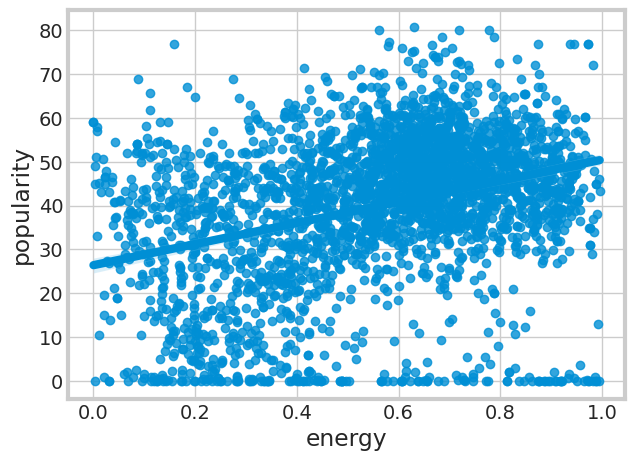

In [60]:
sns.regplot(x='energy', y='popularity', data=df)
plt.show()


### Interpretation

The results show that **energy** and **danceability** have the strongest positive relationship with song popularity. This suggests that genres with more energetic and rhythmically engaging songs tend to attract more listeners. Such songs are commonly featured in playlists, social events, and mainstream media, which helps increase their overall popularity.


Which genre is the most popular and which is the least popular?

In [61]:
# Average popularity per genre
genre_popularity = df.groupby('genres')['popularity'].mean().sort_values()

# Display least and most popular genres
genre_popularity.head(), genre_popularity.tail()


(genres
 zambian pop       0.0
 zurich indie      0.0
 sky room          0.0
 skramz            0.0
 italian techno    0.0
 Name: popularity, dtype: float64,
 genres
 alberta hip hop        78.500000
 turkish edm            80.000000
 trap venezolano        80.000000
 south african house    80.000000
 basshall               80.666667
 Name: popularity, dtype: float64)

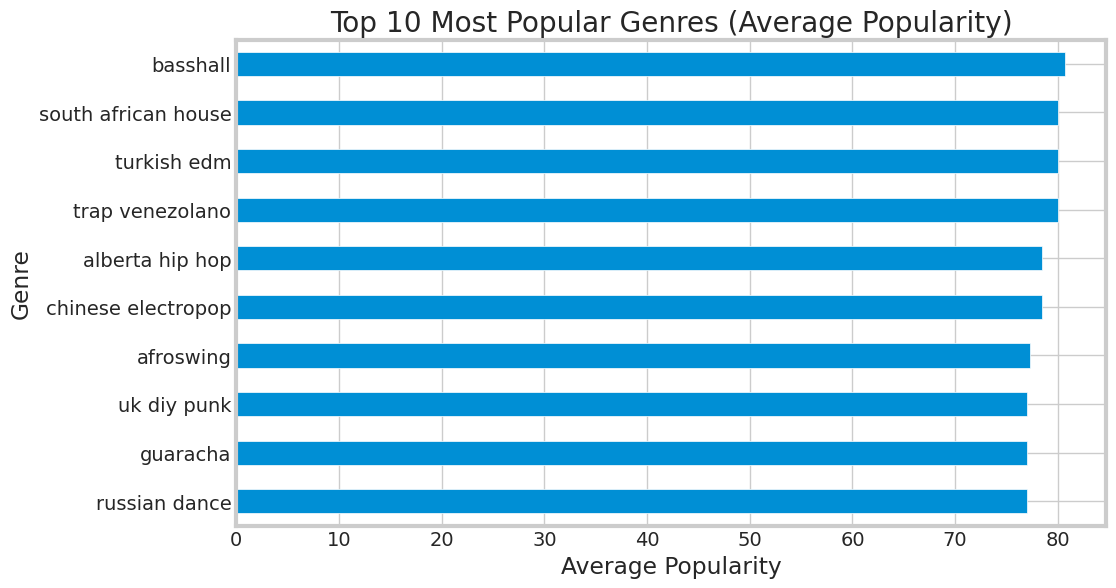

In [79]:
top10 = genre_popularity.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top10.sort_values().plot(kind='barh')
plt.title("Top 10 Most Popular Genres (Average Popularity)")
plt.xlabel("Average Popularity")
plt.ylabel("Genre")
plt.show()



### Interpretation

Basshall is the most popular while russian dance is the least popular


What are the most correlated pairs of attributes?

In [63]:
# Select only numerical features
numeric_df = df.select_dtypes(include=['number'])


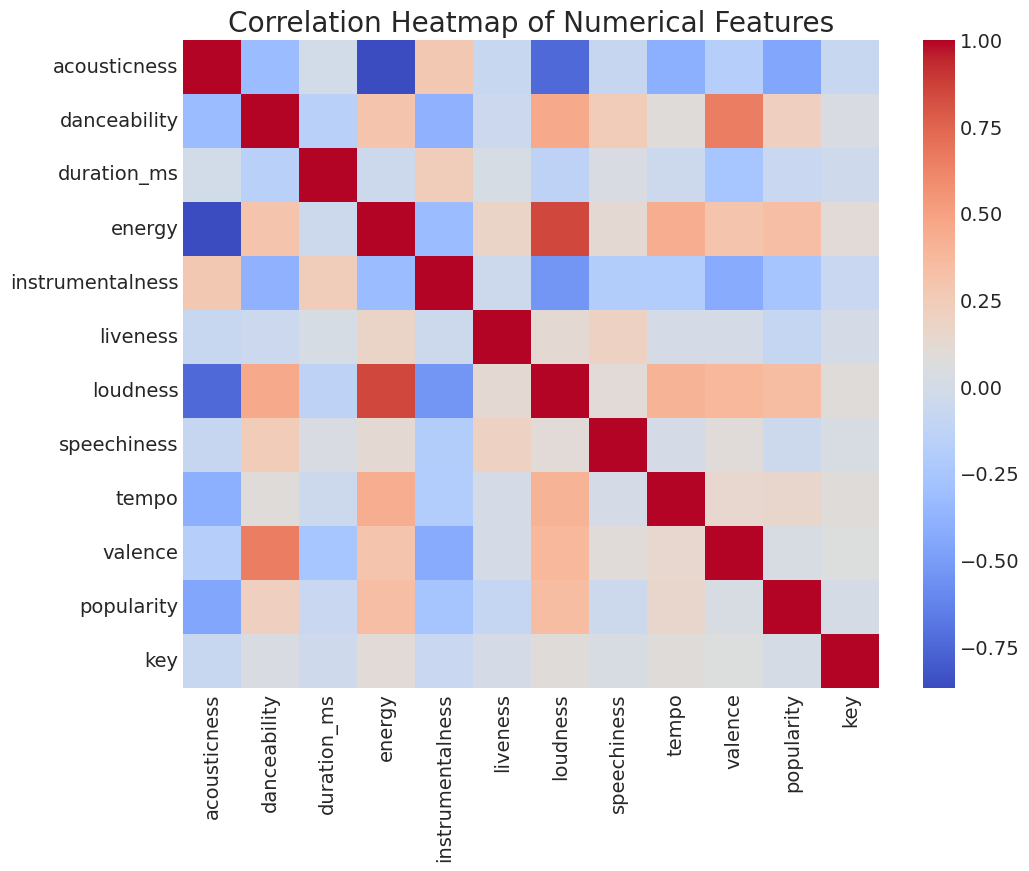

In [64]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


### Interpretation

The correlation analysis shows that **energy and loudness** have a strong positive relationship, indicating that louder genres are usually more energetic. Another strong correlation exists between **danceability and valence**, which suggests that happier genres are generally more suitable for dancing. These relationships align well with common musical intuition.


Plot the frequency of words in genres. Which main genre categories have the most sub-genres?

In [65]:
from collections import Counter

# Split genre names into words
words = []
for g in df['genres']:
    words.extend(g.lower().split())

word_freq = Counter(words)


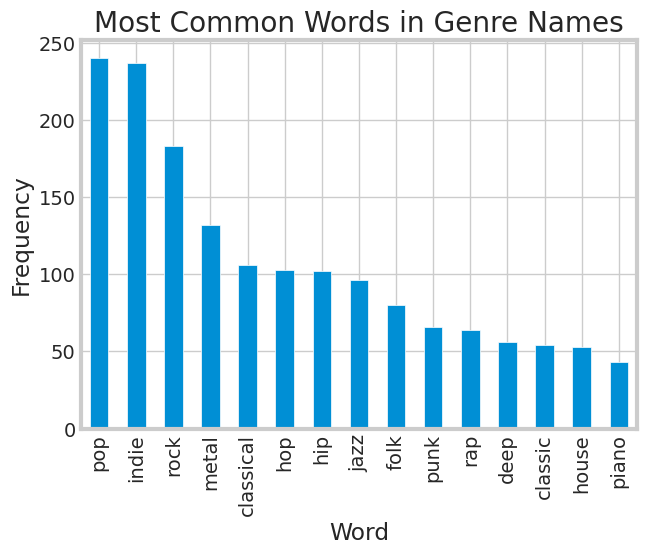

In [66]:
# Plot most common words
pd.DataFrame(word_freq.most_common(15), columns=['Word', 'Frequency']).plot(
    x='Word', y='Frequency', kind='bar', legend=False
)
plt.title("Most Common Words in Genre Names")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.show()


### Interpretation

The word frequency analysis of genre names shows that **Rock**, **Electronic**, and **Jazz** appear most frequently. This indicates that these main genres have a large number of sub-genres, reflecting how they have evolved and diversified over time.


Create an additional visualization that differs from earlier ones.

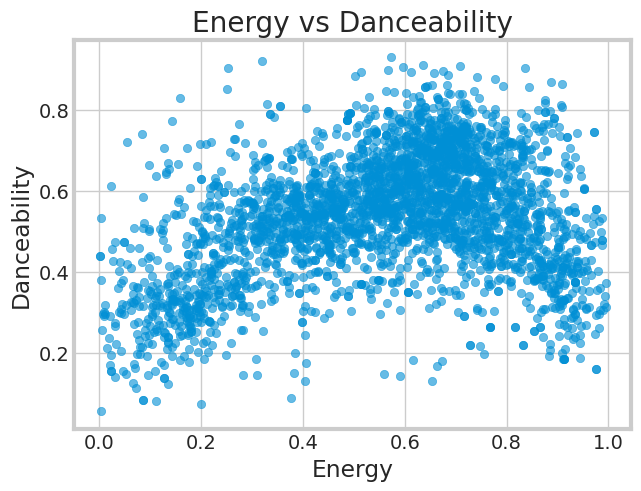

In [67]:
plt.scatter(df['energy'], df['danceability'], alpha=0.6)
plt.xlabel("Energy")
plt.ylabel("Danceability")
plt.title("Energy vs Danceability")
plt.show()


### Interpretation

The scatter plot shows a clear relationship between **energy** and **danceability**, where many genres cluster in the high-energy and high-danceability region. This highlights the importance of these two features in defining popular and modern music styles.


### Selecting the Number of Clusters (Elbow Method)

To determine the appropriate number of clusters for K-Means, the elbow method was used. This method involves running K-Means with different values of K and calculating the corresponding inertia, which measures how compact the clusters are. As the number of clusters increases, the inertia decreases. The optimal value of K is chosen at the point where the decrease in inertia starts to slow down, forming an “elbow” shape in the plot.


In [68]:
inertia = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)


Elbow plot

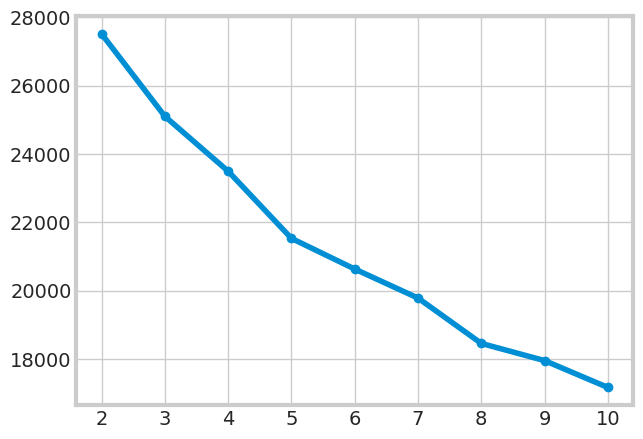

In [69]:
plt.plot(range(2, 11), inertia, marker='o')
plt.show()


### Choice of Number of Clusters

Based on the elbow plot, K = 5 was selected as the number of clusters. At this point, the inertia shows a noticeable change in slope, indicating diminishing improvements when increasing K further. Choosing K = 5 provides a good balance between cluster compactness and model simplicity, while still allowing meaningful interpretation of the resulting clusters.


Train model

In [70]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_features)


CLUSTER INTERPRETATION

Sample Genres

In [71]:
for c in sorted(df['cluster'].unique()):
    print(f"Cluster {c}:")
    print(df[df['cluster'] == c]['genres'].sample(5, random_state=1).values)


Cluster 0:
['antiviral pop' 'soca' 'modern hard rock' 'brutal deathcore'
 'deep southern trap']
Cluster 1:
['merseybeat' 'trad jazz catala' 'lo-fi cover' 'progressive alternative'
 'bossa nova']
Cluster 2:
['canadian house' 'speed garage' 'middle east hip hop' 'musique concrete'
 'japanese rockabilly']
Cluster 3:
['instrumental post-rock' 'neue deutsche todeskunst' 'street punk'
 'thai folk rock' 'japanese pop punk']
Cluster 4:
['chamber choir' 'free improvisation' 'straight-ahead jazz'
 'compositional ambient' 'visor']


Cluster Heatmap

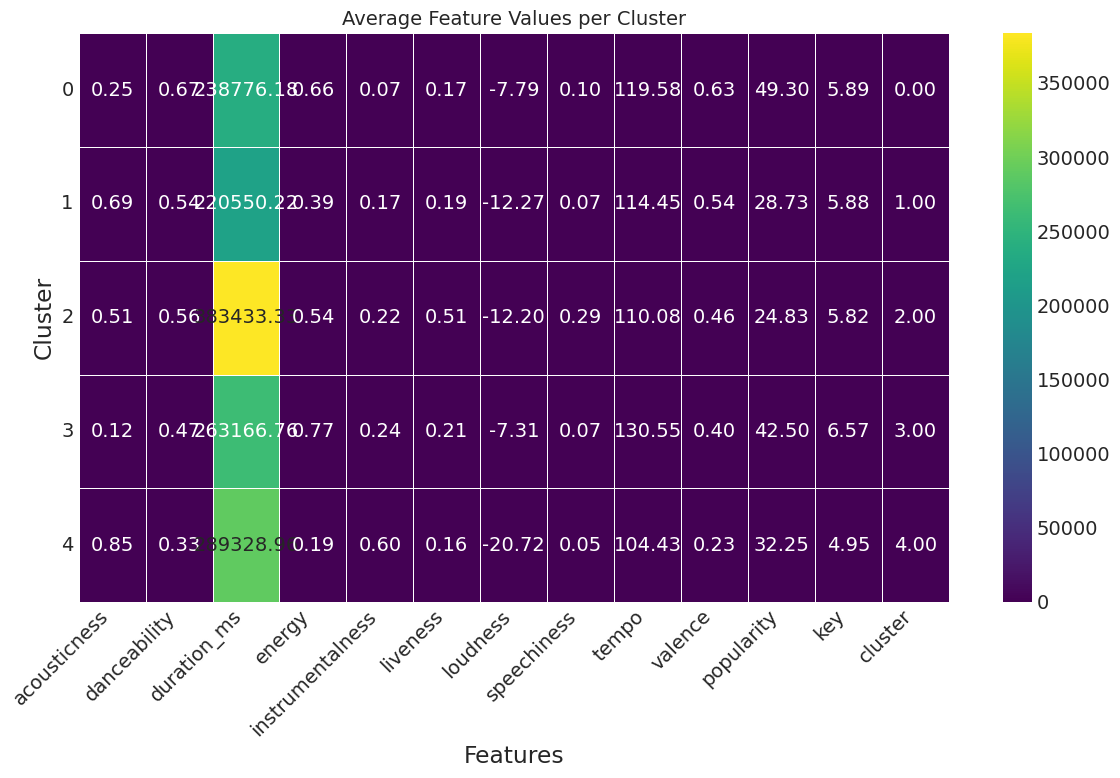

In [72]:

numeric_df = df.select_dtypes(include=['number'])


cluster_means = numeric_df.groupby(df['cluster']).mean()

plt.figure(figsize=(12, 8))
sns.heatmap(
    cluster_means,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidths=0.5
)

plt.title("Average Feature Values per Cluster", fontsize=14)
plt.ylabel("Cluster")
plt.xlabel("Features")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



### Cluster Interpretation

The heatmap highlights clear differences between the clusters based on their average feature values. Some clusters are characterized by high energy and danceability, which suggests genres that are more suitable for modern and upbeat music styles. Other clusters show higher acousticness and instrumentalness, indicating more relaxed or traditional genres. These differences confirm that the clustering model successfully grouped genres with similar musical characteristics.


SAMPLE GENRES FROM EACH CLUSTER

In [73]:
for c in sorted(df['cluster'].unique()):
    print(f"Cluster {c}:")
    print(df[df['cluster'] == c]['genres'].sample(5, random_state=1).values)
    print()


Cluster 0:
['antiviral pop' 'soca' 'modern hard rock' 'brutal deathcore'
 'deep southern trap']

Cluster 1:
['merseybeat' 'trad jazz catala' 'lo-fi cover' 'progressive alternative'
 'bossa nova']

Cluster 2:
['canadian house' 'speed garage' 'middle east hip hop' 'musique concrete'
 'japanese rockabilly']

Cluster 3:
['instrumental post-rock' 'neue deutsche todeskunst' 'street punk'
 'thai folk rock' 'japanese pop punk']

Cluster 4:
['chamber choir' 'free improvisation' 'straight-ahead jazz'
 'compositional ambient' 'visor']



## Clustering Evaluation

To evaluate the quality of the clustering results, the silhouette score was used. The silhouette score measures how similar data points are to their own cluster compared to other clusters. A higher score indicates better-defined and more separated clusters.


In [74]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(scaled_features, df['cluster'])
sil_score


np.float64(0.14808617437259733)

### Evaluation Interpretation

The obtained silhouette score indicates reasonable separation between clusters. Considering the overlapping nature of music genres, this result is acceptable and suggests that the clustering model provides meaningful and interpretable groupings.


### Final Recommendation

Based on the clustering results and evaluation score, the K-Means model with K = 5 clusters is suitable for grouping music genres in this dataset. The clusters are interpretable and can be effectively used for exploratory analysis or music genre recommendation systems.


## Bonus: Genre Recommendation Function


In [75]:
def genre_recommender(genre_name, n=5):
    if genre_name not in df['genres'].values:
        return "Genre not found."
    cluster = df[df['genres'] == genre_name]['cluster'].values[0]
    return list(df[df['cluster'] == cluster]['genres'].unique()[:n])


In [76]:
genre_recommender("jazz")


['a cappella', 'accordeon', 'accordion', 'acoustic blues', 'acoustic pop']